In [ ]:
pip install scikit-learn

In [23]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import tensorflow as tf
print(tf.__version__)


2.18.0


In [27]:
pip install keras


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


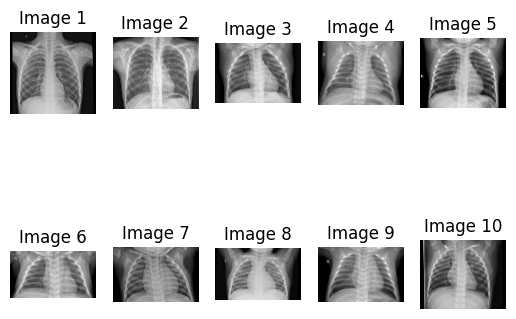

In [28]:
import os
import cv2
import matplotlib.pyplot as plt

# Set your folder path here
folder_path = 'chest_xray/test/NORMAL'

# List the files in the folder (assuming images are .jpg or .png)
image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpeg', '.png'))]

# Print the first 10 images
for i in range(min(10, len(image_files))):  # To make sure we don't exceed the number of available images
    img_path = os.path.join(folder_path, image_files[i])
    
    # Read image using OpenCV (you can also use PIL)
    img = cv2.imread(img_path)
    
    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Plot the image
    plt.subplot(2, 5, i+1)  # 2 rows, 5 columns
    plt.imshow(img_rgb)
    plt.axis('off')  # Remove axis for clarity
    plt.title(f"Image {i+1}")
    
plt.show()


In [29]:
import os
import shutil
import random

# Paths to your dataset
train_dir = 'chest_xray/test'
validation_dir = 'chest_xray/validation'

# Create the validation directory if it doesn't exist
os.makedirs(os.path.join(validation_dir, 'normal'), exist_ok=True)
os.makedirs(os.path.join(validation_dir, 'pneumonia'), exist_ok=True)

# Function to move a fraction of files to the validation folder
def move_to_validation(class_name, fraction=0.2):
    # Path to the class subdirectory
    class_dir = os.path.join(train_dir, class_name)
    
    # Get all files in the class subdirectory
    all_files = os.listdir(class_dir)
    
    # Calculate the number of files to move to validation
    num_files_to_move = int(len(all_files) * fraction)
    
    # Randomly select files to move
    files_to_move = random.sample(all_files, num_files_to_move)
    
    for file in files_to_move:
        # Move the selected file to the validation folder
        src = os.path.join(class_dir, file)
        dst = os.path.join(validation_dir, class_name, file)
        shutil.move(src, dst)

# Move 20% of normal and pneumonia images to validation folder
move_to_validation('normal', fraction=0.2)
move_to_validation('pneumonia', fraction=0.2)


In [30]:
import os
import shutil
import random

# Paths to your dataset
train_dir = 'chest_xray/test'
validation_dir = 'chest_xray/validation'

# Create the validation directory if it doesn't exist
os.makedirs(os.path.join(validation_dir, 'normal'), exist_ok=True)
os.makedirs(os.path.join(validation_dir, 'pneumonia'), exist_ok=True)

# Function to move a fraction of files to the validation folder
def move_to_validation(class_name, fraction=0.2):
    # Path to the class subdirectory
    class_dir = os.path.join(train_dir, class_name)
    
    # Get all files in the class subdirectory
    all_files = os.listdir(class_dir)
    
    # Calculate the number of files to move to validation
    num_files_to_move = int(len(all_files) * fraction)
    
    # Randomly select files to move
    files_to_move = random.sample(all_files, num_files_to_move)
    
    for file in files_to_move:
        # Move the selected file to the validation folder
        src = os.path.join(class_dir, file)
        dst = os.path.join(validation_dir, class_name, file)
        shutil.move(src, dst)

# Move 20% of normal and pneumonia images to validation folder
move_to_validation('normal', fraction=0.2)
move_to_validation('pneumonia', fraction=0.2)


In [31]:
# Directories for train, validation, and test datasets
train_dir = 'chest_xray/train'
validation_dir = 'chest_xray/validation'
test_dir = 'chest_xray/test'


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Image size and batch size
image_size = (224, 224)  # Resize all images to this size
batch_size = 32

# Initialize ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255, 
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

val_test_datagen = ImageDataGenerator(rescale=1./255)


In [33]:
# Flow training images in batches with augmentation
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',  # For binary classification (normal vs pneumonia)
    shuffle=True
)

# Flow validation images in batches
validation_generator = val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Flow test images in batches
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 5229 images belonging to 2 classes.
Found 490 images belonging to 2 classes.
Found 134 images belonging to 2 classes.


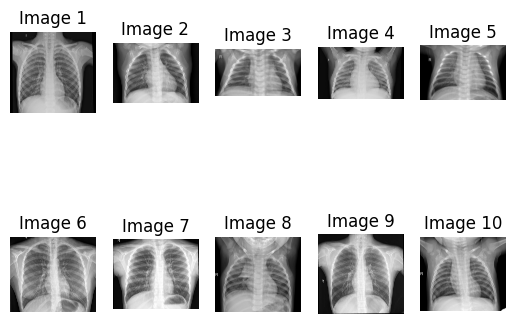

In [1]:
import os
import cv2
import matplotlib.pyplot as plt

# Set your folder path here
folder_path = 'chest_xray/test/NORMAL'

# List the files in the folder (assuming images are .jpg or .png)
image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpeg', '.png'))]

# Print the first 10 images
for i in range(min(10, len(image_files))):  # To make sure we don't exceed the number of available images
    img_path = os.path.join(folder_path, image_files[i])
    
    # Read image using OpenCV (you can also use PIL)
    img = cv2.imread(img_path)
    
    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Plot the image
    plt.subplot(2, 5, i+1)  # 2 rows, 5 columns
    plt.imshow(img_rgb)
    plt.axis('off')  # Remove axis for clarity
    plt.title(f"Image {i+1}")
    
plt.show()


In [35]:
# Import necessary modules
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential()

# 1st Convolutional Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Convolutional Layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Convolutional Layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the results to feed into a fully connected layer
model.add(Flatten())

# Fully connected layer with 512 neurons
model.add(Dense(512, activation='relu'))

# Dropout layer to reduce overfitting
model.add(Dropout(0.5))

# Output layer (binary classification: normal or pneumonia)
model.add(Dense(1, activation='sigmoid'))  # sigmoid for binary classification

# Print the model summary
model.summary()


C:\Users\A\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary to check architecture
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)


C:\Users\A\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 620s 4s/step - accuracy: 0.7364 - loss: 0.6387 - val_accuracy: 0.6479 - val_loss: 0.5811
Epoch 2/10
  1/163 ━━━━━━━━━━━━━━━━━━━━ 8:23 3s/step - accuracy: 0.9688 - loss: 0.3120

C:\Users\A\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - accuracy: 0.9688 - loss: 0.3120 - val_accuracy: 0.6604 - val_loss: 0.6323
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 646s 4s/step - accuracy: 0.8389 - loss: 0.3495 - val_accuracy: 0.8542 - val_loss: 0.3869
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.7812 - loss: 0.4749 - val_accuracy: 0.8708 - val_loss: 0.3730
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 461s 3s/step - accuracy: 0.8609 - loss: 0.3034 - val_accuracy: 0.7563 - val_loss: 0.4915
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.8125 - loss: 0.2862 - val_accuracy: 0.7646 - val_loss: 0.4848
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.8678 - loss: 0.3077 - val_accuracy: 0.8938 - val_loss: 0.2784
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9062 - loss: 0.2394 - val_accuracy: 0.8917 - val_loss: 0.2763
Epoch 9/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.8744 - loss: 0.2763 - val_accuracy: 

In [38]:
# Predict on test data
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype("int32")


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 506ms/step


In [40]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the test set
predictions = model.predict(test_generator, steps=len(test_generator), verbose=1)

# Convert predictions to class labels (for binary classification)
predicted_classes = (predictions > 0.5).astype("int32")

# If it's multi-class classification, use:
# predicted_classes = np.argmax(predictions, axis=-1)

# Print classification report
print("Classification Report:")
print(classification_report(test_generator.classes, predicted_classes))

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(test_generator.classes, predicted_classes))


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 435ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75      0.85        51
           1       0.86      1.00      0.93        83

    accuracy                           0.90       134
   macro avg       0.93      0.87      0.89       134
weighted avg       0.92      0.90      0.90       134

Confusion Matrix:
[[38 13]
 [ 0 83]]


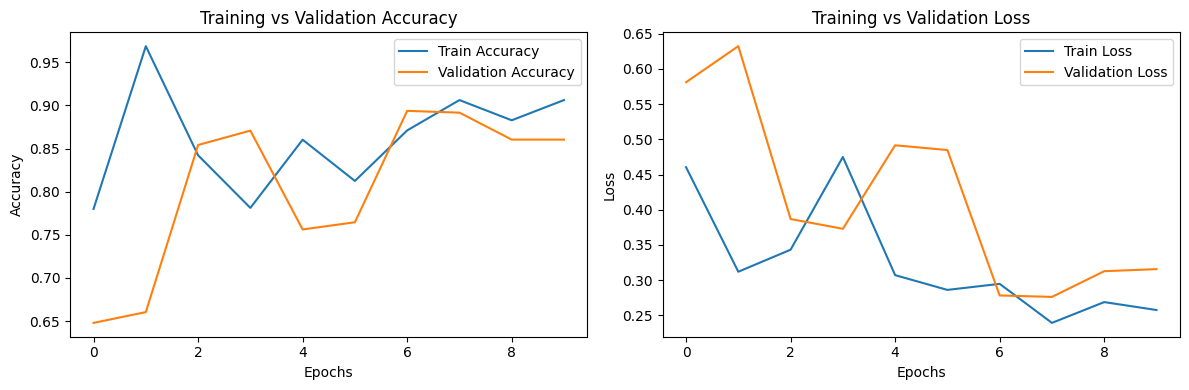

In [41]:
# Plot training and validation accuracy/loss curves
plt.figure(figsize=(12, 4))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step


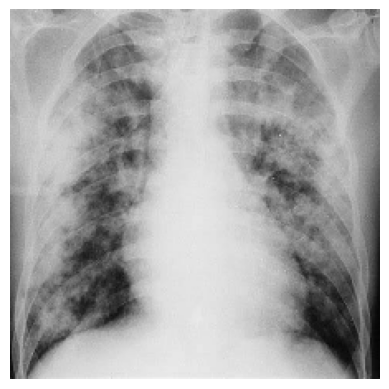

Predicted class: [[1]]


In [44]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to the image you want to predict
img_path = 'image.jpeg'  # Replace with your image path

# Load the image and resize it to match the model's expected input size
img = image.load_img(img_path, target_size=(224, 224))

# Convert the image to a numpy array
img_array = image.img_to_array(img)

# Rescale the image (same scaling factor used during training)
img_array = img_array / 255.0  # Rescale pixel values between 0 and 1

# Add an extra dimension to match the batch shape (1, 224, 224, 3)
img_array = np.expand_dims(img_array, axis=0)

# Make prediction using the trained model
predictions = model.predict(img_array)

# For binary classification, use thresholding to get the class label (0 or 1)
predicted_class = (predictions > 0.5).astype("int32")

# For multi-class classification, use np.argmax to get the class with highest probability
# predicted_class = np.argmax(predictions, axis=-1)

# Display the image and the predicted class
plt.imshow(img)
plt.axis('off')  # Hide the axis
plt.show()

# Print the predicted class
print("Predicted class:", predicted_class)
